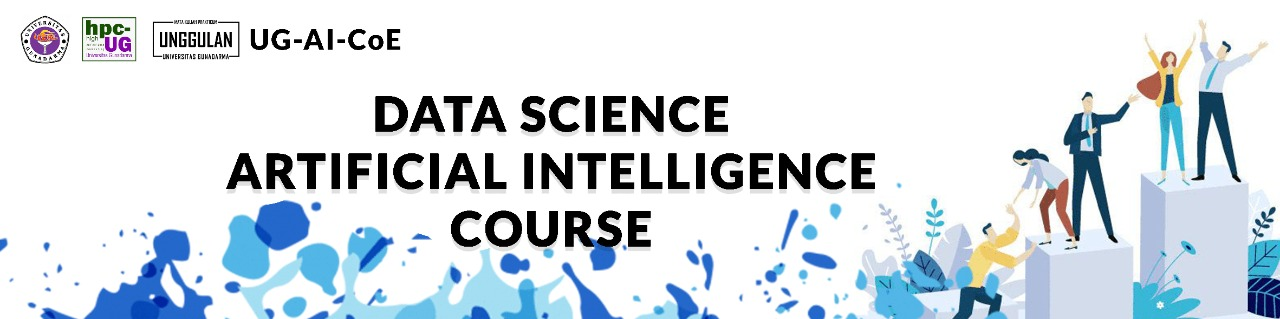

# Tugas Mandiri
---
Tugas mandiri ini digunakan pada kegiatan Kursus Data Science yang merupakan pembekalan bagi mahasiswa Universitas Gunadarma untuk Skema Supervisor Ilmuwan Data (Data Scientist Supervisor).

### Pertemuan 4 - Semester 7

## Implementasi Clustering untuk Menemukan Pola pada Data dengan Metodologi CRISP-DM


### Deskripsi Tugas
1. Mahasiswa harus membuat Project Data Science Sederhana dengan menggunakan algoritma clustering untuk menemukan kelompok atau pola tersembunyi pada suatu dataset.
2. Project dikerjakan secara lengkap mengikuti tahapan **CRISP-DM (Cross-Industry Standard Process for Data Mining)**, mulai dari Business Understanding hingga tahap Deployment.
3. Mahasiswa bebas memilih topik atau permasalahan yang relevan, selama project memiliki tujuan clustering yang jelas dan dataset memenuhi ketentuan yang telah ditetapkan.

### Ketentuan Dataset

Dataset yang digunakan harus memenuhi ketentuan berikut:
1. Berupa tabular dataset (.csv, .xlsx, atau sejenisnya).
2. Minimal 1000 baris dan 8 kolom.
3. Memiliki minimal 3 fitur numerik yang dapat digunakan untuk clustering.
4. Dataset memiliki karakteristik yang memungkinkan untuk dilakukan pengelompokan atau segmentasi.
5. Sumber dataset wajib dicantumkan dan berasal dari sumber yang jelas, seperti Kaggle, UCI, data.go.id, open data, atau dataset hasil pengumpulan sendiri.
6. Mahasiswa wajib menjelaskan secara singkat alasan dataset tersebut sesuai untuk permasalahan clustering.


<b>Catatan: Nilai akan dikurangi apabila dataset tidak memenuhi ketentuan.</b>

### Ketentuan Pengumpulan

Mahasiswa wajib mengumpulkan file berikut:
1. File Jupyter Notebook dengan format (`.ipynb`): Berisi seluruh proses CRISP-DM dari Business Understanding sampai Evaluation. **Notebook harus dapat dijalankan tanpa error.**

2. File Dataset: File dataset yang digunakan atau link sumber dataset.

3. Source Code Deployment
    <br> File yang digunakan untuk menjalankan aplikasi, misalnya: <br>
         

    *   app.py
    *   requirements.txt
    *   file konfigurasi atau file pendukung lainnya.


4. Link Deployment: Link aplikasi yang sudah dapat diakses melalui platform Streamlit.

<br>

<b>Seluruh file project dikumpulkan dalam satu folder Google Drive dengan akses *Anyone with the link → Editor*.</b> Tautan folder Google Drive kemudian dikumpulkan melalui Virtual Class sesuai dengan batas waktu yang telah ditentukan.

## Business Understanding

### Tujuan
Membangun model prediktif (klasifikasi) yang mampu mengelompokkan susu ke dalam 3 kelas: Low (Bad), Medium (Moderate), dan High (Good) berdasarkan 7 parameter fisik dan kimia (pH, Temperature, Taste, Odor, Fat, Turbidity, dan Color).

## Data Understanding

### import liblary

In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

### memuat data

In [8]:
df = pd.read_csv('weather_classification_data.csv')
df.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy


In [9]:
df.shape

(13200, 11)

#### Deskripsi kolom:

- Temperature (numerik): Suhu dalam derajat Celcius, dengan rentang mulai dari suhu yang sangat dingin hingga panas yang ekstrem.
- Humidity (numerik): Persentase kelembapan, termasuk nilai di atas 100% untuk memasukkan pencilan.
- Wind Speed (numerik): Kecepatan angin dalam kilometer per jam, dengan rentang yang mencakup nilai tinggi yang tidak realistis.
- Precipitation (%) (numerik): Persentase curah hujan, termasuk nilai-nilai pencilan.
- Cloud Cover (kategorikal): Deskripsi mengenai kondisi tutupan awan.
- Atmospheric Pressure (numerik): Tekanan atmosfer dalam hPa, mencakup rentang nilai yang luas.
- UV Index (numerik): Indeks UV, yang menunjukkan tingkat kekuatan radiasi ultraviolet.
- Season (kategorikal): Musim pada saat data tersebut dicatat.
- Visibility (km) (numerik): Jarak pandang dalam satuan kilometer, termasuk nilai yang sangat rendah atau sangat tinggi.
- Location (kategorikal): Jenis lokasi di mana data tersebut dicatat.
- Weather Type (kategorikal): Variabel target untuk proses klasifikasi, yang menunjukkan jenis cuacanya.

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Cloud Cover           13200 non-null  object 
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  object 
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  object 
 10  Weather Type          13200 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 1.1+ MB


In [11]:
df.describe()

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km)
count,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000
mean,19.127576,68.710833,9.832197,53.644394,1005.827896,4.005758,5.462917
std,17.386327,20.194248,6.908704,31.946541,37.199589,3.856600,3.371499
min,-25.000000,20.000000,0.000000,0.000000,800.120000,0.000000,0.000000
25%,4.000000,57.000000,5.000000,19.000000,994.800000,1.000000,3.000000
50%,21.000000,70.000000,9.000000,58.000000,1007.650000,3.000000,5.000000
75%,31.000000,84.000000,13.500000,82.000000,1016.772500,7.000000,7.500000
max,109.000000,109.000000,48.500000,109.000000,1199.210000,14.000000,20.000000


berdasarkan hasil dari deskripsi data di atas didapat erdapat nilai maksimum yang sangat tinggi dan identik pada variabel Temperature, Humidity, dan Precipitation (%)

### Pemeriksaan Missing Value

In [12]:
df.isna().sum()

Temperature             0
Humidity                0
Wind Speed              0
Precipitation (%)       0
Cloud Cover             0
Atmospheric Pressure    0
UV Index                0
Season                  0
Visibility (km)         0
Location                0
Weather Type            0
dtype: int64

### Pemeriksaan Duplikasi Data

In [13]:
df.duplicated().sum()

0

#### Distribusi Target

In [15]:
print("\nDistribusi Kelas Target (Weather Type):")
print(df['Weather Type'].value_counts())


Distribusi Kelas Target (Weather Type):
Weather Type
Rainy     3300
Cloudy    3300
Sunny     3300
Snowy     3300
Name: count, dtype: int64


### Deteksi Outlier

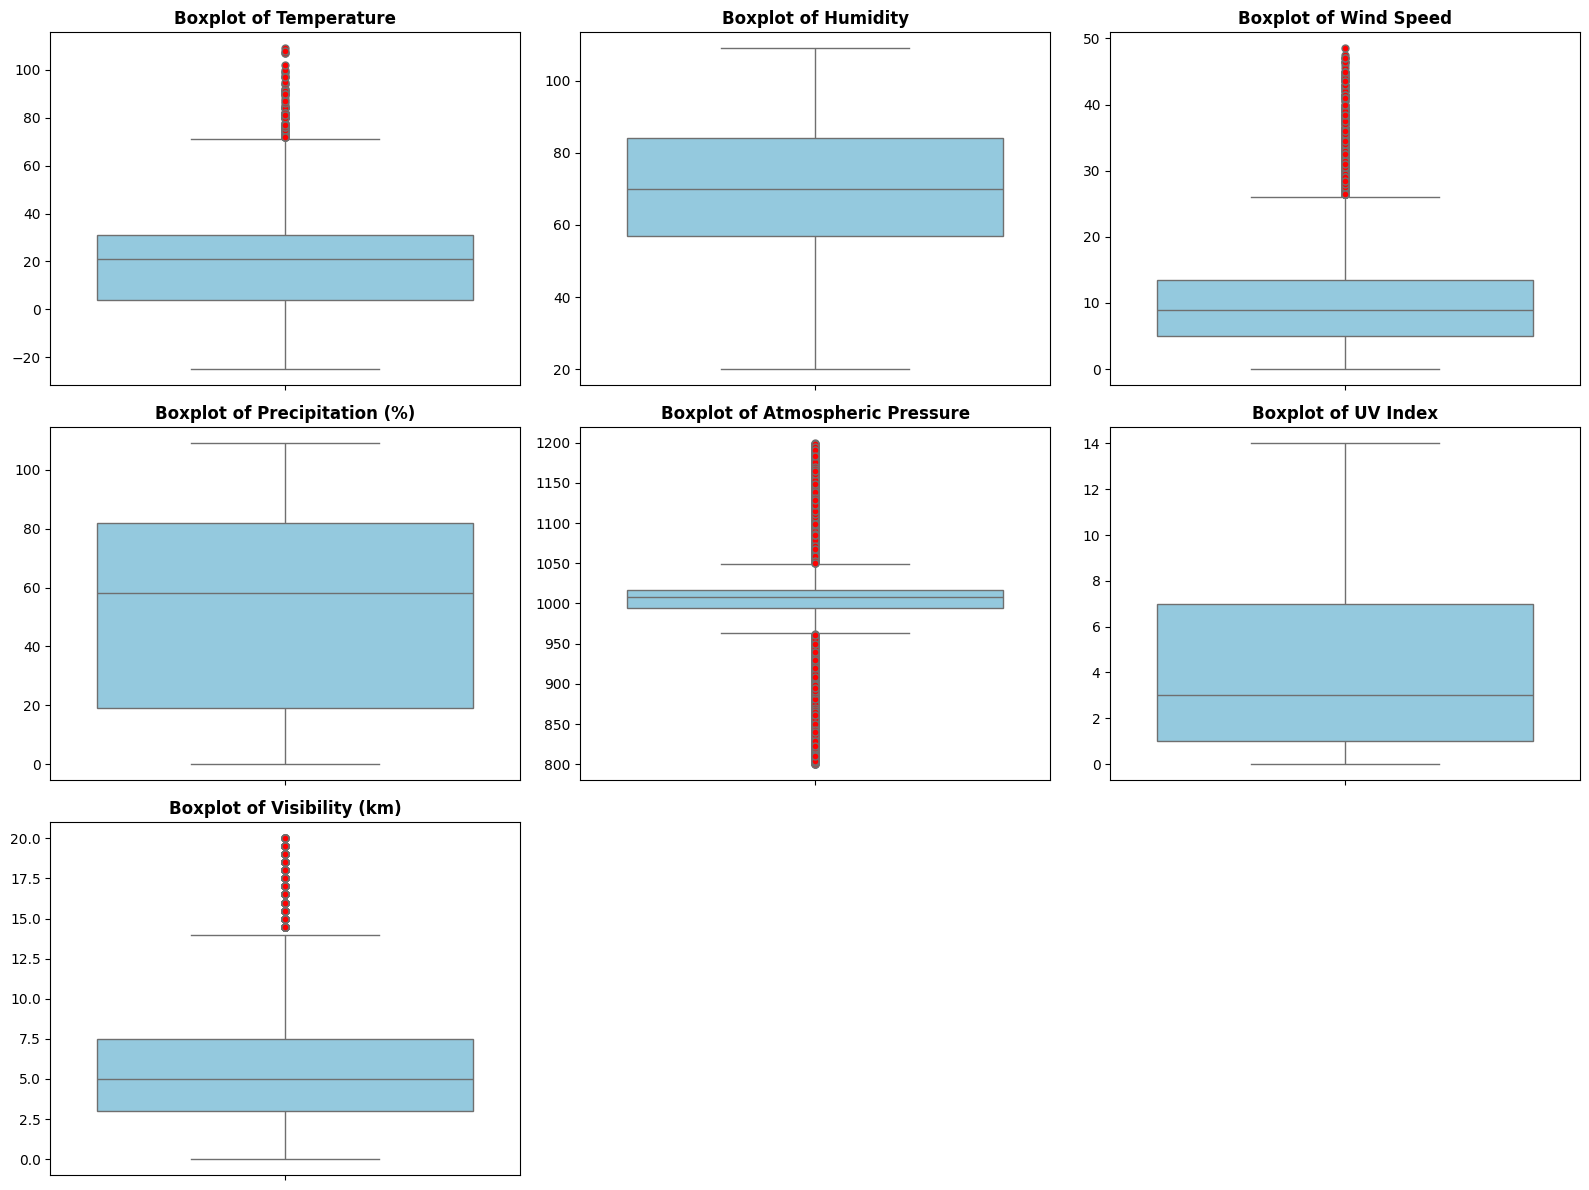

In [16]:
numeric_cols = [
    'Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)', 
    'Atmospheric Pressure', 'UV Index', 'Visibility (km)'
]

plt.figure(figsize=(16, 12))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col], color='skyblue', flierprops={'marker': 'o', 'markerfacecolor': 'red', 'markersize': 5})
    plt.title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
    plt.ylabel('')
plt.tight_layout()
plt.show()

berdasarkan output di atas didapat outlier pada kolom Temperature, Wind Speed, Atmospheric Pressure dan Visibility (km)

## Data Preparation

berdasarkan identifikawi di atas langkah pembersihan yang harus dilakukan adalah menangani outlier dan encoding data

### menangani outlier mengginakan iqr

In [18]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

print(f"Jumlah baris setelah penghapusan outlier: {len(df)}")

Jumlah baris setelah penghapusan outlier: 11586


### data encoding

In [21]:
le = LabelEncoder()
df['Target'] = le.fit_transform(df['Weather Type'])
mapping_kelas = dict(zip(le.classes_, le.transform(le.classes_)))
print("\nPemetaan Kelas Target:", mapping_kelas)

categorical_cols = ['Cloud Cover', 'Season', 'Location']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df_final = df_encoded.drop('Weather Type', axis=1)

print(df_final.head())


Pemetaan Kelas Target: {'Cloudy': 0, 'Rainy': 1, 'Snowy': 2, 'Sunny': 3}
   Temperature  Humidity  Wind Speed  Precipitation (%)  Atmospheric Pressure  \
0         14.0        73         9.5               82.0               1010.82   
1         39.0        96         8.5               71.0               1011.43   
2         30.0        64         7.0               16.0               1018.72   
3         38.0        83         1.5               82.0               1026.25   
4         27.0        74        17.0               66.0                990.67   

   UV Index  Visibility (km)  Target  Cloud Cover_cloudy  \
0         2              3.5       1               False   
1         7             10.0       0               False   
2         5              5.5       3               False   
3         7              1.0       3               False   
4         1              2.5       1               False   

   Cloud Cover_overcast  Cloud Cover_partly cloudy  Season_Spring  \
0        

### data spliting

In [22]:
X = df_final.drop('Target', axis=1)
y = df_final['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Jumlah data latih: {X_train.shape[0]}")
print(f"Jumlah data uji: {X_test.shape[0]}")

Jumlah data latih: 9268
Jumlah data uji: 2318


### standarisasi

In [24]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Modeling

In [25]:
svm_model = SVC(kernel='rbf', C=1.0, random_state=42)
svm_model.fit(X_train_scaled, y_train)
y_pred = svm_model.predict(X_test_scaled)

#### melakuklan hyperparameter tuning

In [26]:
akurasi = accuracy_score(y_test, y_pred)
print(f"Akurasi Model: {akurasi * 100:.2f}%\n")

Akurasi Model: 97.24%



## Evaluation

In [27]:
target_names = le.classes_ 
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

Classification Report:
              precision    recall  f1-score   support

      Cloudy       0.95      0.96      0.96       597
       Rainy       0.96      0.98      0.97       574
       Snowy       0.99      0.98      0.99       546
       Sunny       0.99      0.97      0.98       601

    accuracy                           0.97      2318
   macro avg       0.97      0.97      0.97      2318
weighted avg       0.97      0.97      0.97      2318



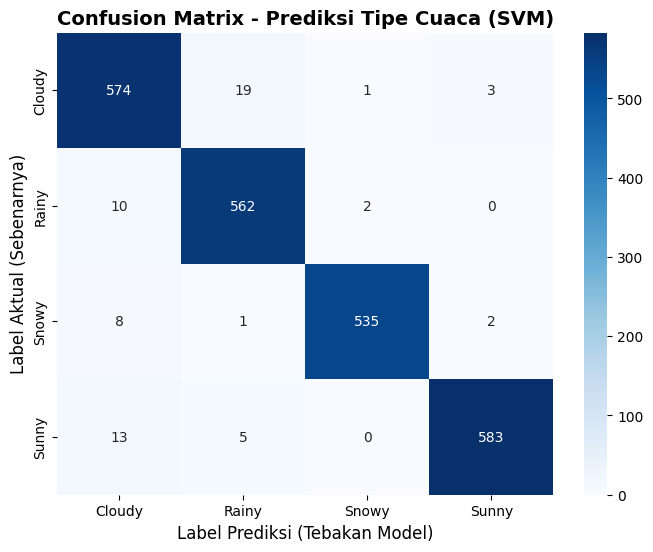

In [28]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - Prediksi Tipe Cuaca (SVM)', fontsize=14, fontweight='bold')
plt.ylabel('Label Aktual (Sebenarnya)', fontsize=12)
plt.xlabel('Label Prediksi (Tebakan Model)', fontsize=12)
plt.show()

berdasarkan hasil evaluasi model dapat memahami pola dengan baik dengan akurasi sebesar97%

## Deployment

In [30]:
file_model = 'svm_weather_model.pkl'
joblib.dump(svm_model, file_model)
print(f"Model SVM berhasil disimpan sebagai: {file_model}")

Model SVM berhasil disimpan sebagai: svm_weather_model.pkl


In [31]:
file_scaler = 'scaler_weather.pkl'
joblib.dump(scaler, file_scaler)
print(f"Scaler berhasil disimpan sebagai: {file_scaler}")

Scaler berhasil disimpan sebagai: scaler_weather.pkl


In [32]:
file_le = 'label_encoder_weather.pkl'
joblib.dump(le, file_le)
print(f"Label Encoder berhasil disimpan sebagai: {file_le}")

Label Encoder berhasil disimpan sebagai: label_encoder_weather.pkl


In [33]:
print(X_train.columns.tolist())

['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)', 'Atmospheric Pressure', 'UV Index', 'Visibility (km)', 'Cloud Cover_cloudy', 'Cloud Cover_overcast', 'Cloud Cover_partly cloudy', 'Season_Spring', 'Season_Summer', 'Season_Winter', 'Location_inland', 'Location_mountain']


---

Copyright © 2026 by Tim Pengembangan DGX, Universitas Gunadarma


https://www.hpc-hub.gunadarma.ac.id/